# Natgas-Winter
### Is the winter natural-gas spike a tradable season?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Winter is a tailwind?: Busted](https://img.shields.io/badge/Winter_tailwind%3F-Busted-8b949e?style=flat-square)

Every winter, natural-gas demand peaks as homes and businesses crank up the heat. Folk wisdom says: buy UNG in October, ride the spike through March, sell. It sounds intuitive — but UNG is not natural gas. It is a monthly futures roll, and when the futures curve slopes upward (contango), each roll costs you real money. This is the widow-maker of commodity ETFs: the spot might spike, but the ETF loses anyway.

> This is the plain-language notebook. The regression and sub-period slopes are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (natgas_winter/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from natgas_winter import data, strategy as st
from quantlab import repro
d = repro.as_of(data.fetch_ung())   # cache-first; hole-free monthly grid, pinned as-of
reg = st.winter_premium(d["ung"])
seasonal = st.seasonal_returns(d["ung"])
bh = st.buy_hold_returns(d["ung"])


## The answer first

| The claim | The data (UNG 2007-2026, 229 months) |
|---|---|
| "Winter demand lifts natgas prices" | True for spot. But UNG average **-3.56%/month** in winter vs **-0.04%/month** in summer. |
| "Buy Oct, sell Mar" | Seasonal strategy CAGR **-24.5%**, Sharpe **-0.60** — worse than buy-and-hold (-28.2%, Sharpe -0.45). |
| "A durable seasonal edge" | Negative slope in both 2007-2015 (t = -0.99) and 2016-2026 (t = -1.72). |

> The widow-maker earns its name.

## 1 · The claim

Natural gas demand peaks in winter. Heating degree-days drive consumption above injection capacity. Folk traders say: capture this in UNG (the largest retail natgas vehicle), buy in fall, sell when winter ends.

## 2 · What UNG actually holds

UNG does not hold physical natural gas. It holds **front-month futures contracts** and rolls them before expiry into the next contract. When the futures curve is in **contango** (distant months more expensive than nearby), rolling means selling cheap and buying dear — a guaranteed monthly loss independent of where spot goes. In natural gas, contango is the default condition: the market pays a premium for future delivery (storage costs, weather optionality). Winter is precisely when the contango is steepest — and when roll drag is worst.

## 3 · How would we even know?

Regress monthly UNG returns on a winter dummy (1 = Oct-Mar, 0 = Apr-Sep): positive slope + significant t-stat would support the claim. Then race the seasonal strategy (in during Oct-Mar, cash=0 otherwise) against buy-and-hold UNG on Sharpe.

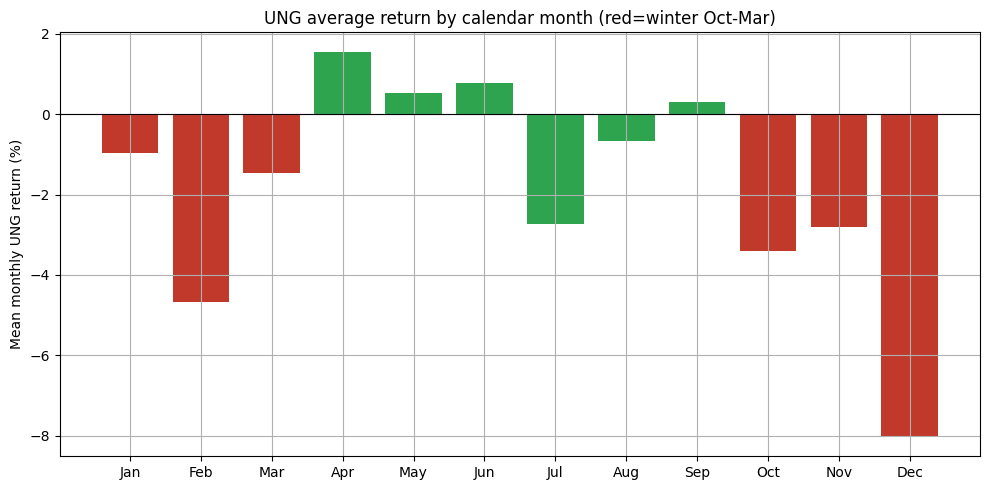

Winter (Oct-Mar) mean: -3.56%/month
Non-winter (Apr-Sep) mean: -0.04%/month


In [2]:
# Winter vs non-winter returns by month
sig = st.seasonal_signal(pd.DatetimeIndex(d.index))
monthly_means = d.groupby(d.index.month)['ung'].mean() * 100
colors = ['#c0392b' if m in st.WINTER_MONTHS else '#2ea44f' for m in monthly_means.index]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(monthly_means.index, monthly_means.values, color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Mean monthly UNG return (%)')
ax.set_title('UNG average return by calendar month (red=winter Oct-Mar)')
plt.tight_layout(); plt.show()
print(f'Winter (Oct-Mar) mean: {d[sig==1]["ung"].mean()*100:.2f}%/month')
print(f'Non-winter (Apr-Sep) mean: {d[sig==0]["ung"].mean()*100:.2f}%/month')

## 4 · The teardown

The chart says it all: the 'winter spike' in natural-gas *demand* does not translate into positive UNG *returns*. Winter months average −3.56%/month — the worst cluster of the calendar. Summer months (Apr-Sep) are nearly flat (−0.04%/month). The seasonal trade concentrates exposure in the worst months.

,cagr,sharpe,max_drawdown
seasonal (Oct-Mar),-24.5%,-0.60,-100%
buy & hold UNG,-28.2%,-0.45,-100%


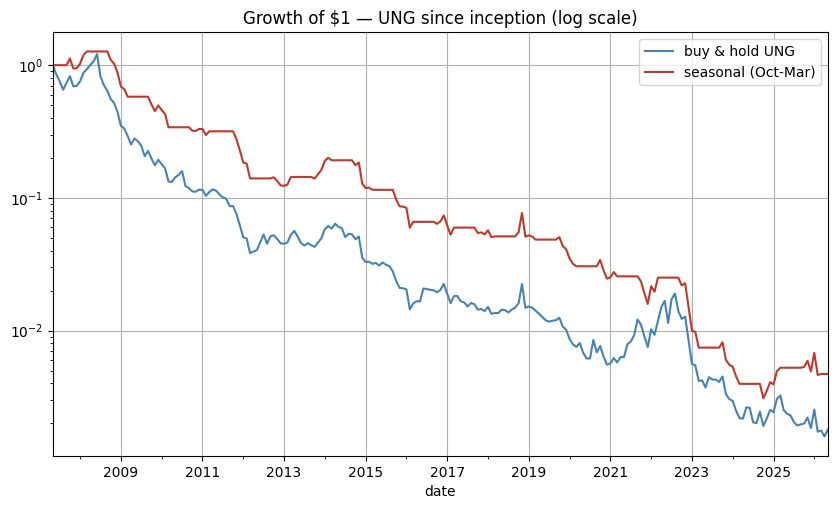

In [3]:
rows = {'seasonal (Oct-Mar)': st.summary(seasonal), 'buy & hold UNG': st.summary(bh)}
t = pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown']]
display(t.style.format({'cagr':'{:.1%}','sharpe':'{:.2f}','max_drawdown':'{:.0%}'}))
eq_s = (1 + seasonal).cumprod(); eq_b = (1 + bh).cumprod()
ax = eq_b.plot(label='buy & hold UNG', lw=1.5, color='steelblue')
eq_s.plot(ax=ax, label='seasonal (Oct-Mar)', lw=1.5, color='#c0392b')
ax.set_yscale('log'); ax.set_title('Growth of $1 — UNG since inception (log scale)')
ax.legend(); plt.show()

**Read it plainly.** Both lines go to near-zero — UNG has lost ~99.8% since inception. The seasonal strategy (red) trails the already-terrible buy-and-hold (blue) because it concentrates its exposure in the worst calendar months. The widow-maker lives up to its name.

## 5 · The verdict

**Signal: None** — the winter slope is −0.035 (t = −1.96), wrong sign, wrong significance. **Tradability: Mirage** — seasonal Sharpe −0.60 versus buy-and-hold −0.45. **Winter is a tailwind?: Busted.**

## 6 · Could you actually trade it?

You could set a calendar reminder every October to buy UNG. You'd lose roughly a quarter of your stake every year. The fundamental demand season is real — but the futures market prices it in, and then the roll drag extracts a monthly toll on top. There is no edge here; only a slow and predictable destruction of capital.

## 7 · Going further

For actual natgas exposure, researchers look at: (a) backwardated regimes (rare in natgas, but real carry exists then); (b) natural-gas producer equities (EQT, CHK) which carry operational leverage to spot without roll drag; (c) calendar spread strategies that earn the roll yield *from the other side*. The seasonal long in UNG is not among them.